# Task 1: Natural Gas

After asking around for the source of the existing data, you learn that the current process is to take a monthly snapshot of prices from a market data provider, which represents the market price of natural gas delivered at the end of each calendar month. This data is available for roughly the next 18 months and is combined with historical prices in a time series database. After gaining access, you are able to download the data in a CSV file.

You should use this monthly snapshot to produce a varying picture of the existing price data, as well as an extrapolation for an extra year, in case the client needs an indicative price for a longer-term storage contract.

Download the monthly natural gas price data.
Each point in the data set corresponds to the purchase price of natural gas at the end of a month, from 31st October 2020 to 30th September 2024.
Analyze the data to estimate the purchase price of gas at any date in the past and extrapolate it for one year into the future. 
Your code should take a date as input and return a price estimate.
Try to visualize the data to find patterns and consider what factors might cause the price of natural gas to vary. This can include looking at months of the year for seasonal trends that affect the prices, but market holidays, weekends, and bank holidays need not be accounted for.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from datetime import timedelta

In [21]:
# Load the CSV file containing natural gas prices
data = pd.read_csv("natural_gas_prices.csv")
data["Date"] = pd.to_datetime(data["Date"])
data.set_index("Date", inplace=True)

/var/folders/pr/b4gcntys4052c6mv0215d8680000gp/T/ipykernel_30017/721517225.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data["Date"] = pd.to_datetime(data["Date"])


In [24]:
XLABEL = "Date"
YLABEL = "Price (USD)"
PLOT_NAME = "Historical Prices"

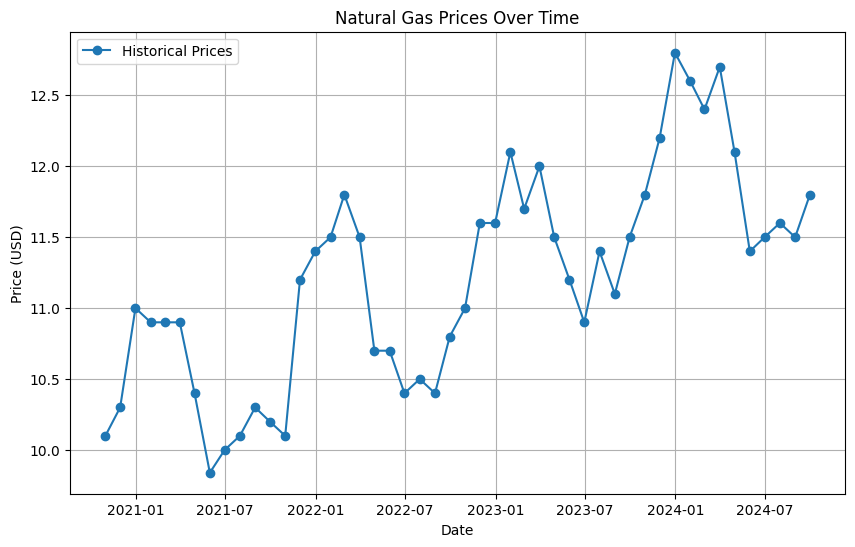

In [ ]:
# Visualise the data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data["Price"], label=PLOT_NAME, marker="o")
plt.title("Natural Gas Prices Over Time")
plt.xlabel(XLABEL)
plt.ylabel(YLABEL)
plt.legend()
plt.grid()
plt.show()

In [26]:
def estimate_price(date):
    """Interpolation function to estimate price for any date"""
    date = pd.to_datetime(date)
    if date < data.index.min() or date > data.index.max():
        raise ValueError("Date out of range for interpolation.")
    interpolation = interp1d(
        data.index.values.astype(np.int64), data["Price"], kind="linear"
    )
    return interpolation(date.value)

In [27]:
def extrapolate_prices():
    """Extrapolation for one year into the future"""
    last_date = data.index.max()
    future_dates = [last_date + timedelta(days=30 * i) for i in range(1, 13)]
    future_prices = []
    for i in range(1, 13):
        # Simple extrapolation using the average monthly change
        avg_monthly_change = data["Price"].diff().mean()
        future_prices.append(data["Price"].iloc[-1] + avg_monthly_change * i)
    return pd.DataFrame({"Date": future_dates, "Price": future_prices})

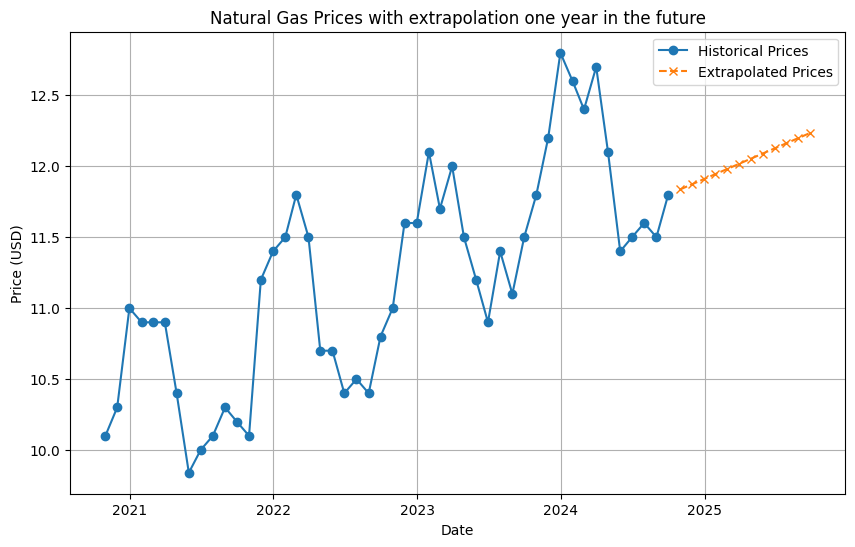

In [28]:
# Visualise the extrapolated data
future_data = extrapolate_prices()
plt.figure(figsize=(10, 6))
plt.plot(data.index, data["Price"], label=PLOT_NAME, marker="o")
plt.plot(
    future_data["Date"],
    future_data["Price"],
    label="Extrapolated Prices",
    linestyle="--",
    marker="x",
)
plt.title("Natural Gas Prices with extrapolation one year in the future")
plt.xlabel(XLABEL)
plt.ylabel(YLABEL)
plt.legend()
plt.grid()
plt.show()

In [29]:
# Example usage
input_date = "2023-06-15"
estimated_price = estimate_price(input_date)
print(f"Estimated price for {input_date}: ${estimated_price:.2f}")

# Save extrapolated data to a new CSV file
future_data.to_csv("extrapolated_natural_gas_prices.csv", index=False)

Estimated price for 2023-06-15: $11.05


### Line of Best Fit

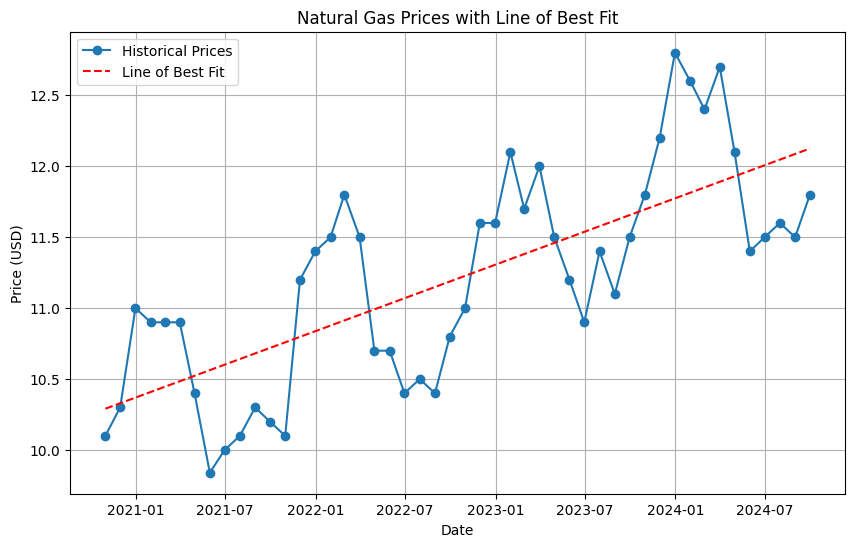

In [30]:
# Fit a line of best fit to the historical data
coefficients = np.polyfit(data.index.values.astype(np.int64), data["Price"], deg=1)
line_of_best_fit = np.poly1d(coefficients)

# Generate values for the line of best fit
x_values = data.index.values.astype(np.int64)
y_values = line_of_best_fit(x_values)

# Visualise the line of best fit
plt.figure(figsize=(10, 6))
plt.plot(data.index, data["Price"], label=PLOT_NAME, marker="o")
plt.plot(data.index, y_values, label="Line of Best Fit", color="red", linestyle="--")
plt.title("Natural Gas Prices with Line of Best Fit")
plt.xlabel(XLABEL)
plt.ylabel(YLABEL)
plt.legend()
plt.grid()
plt.show()